# Importing the needed libraries

In [ ]:
pip install nltk

In [ ]:
pip install networkx

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk as nk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import euclidean, cityblock, cosine
import networkx as nx
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.cluster import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans, HDBSCAN, MeanShift, AffinityPropagation, MiniBatchKMeans, AgglomerativeClustering, BisectingKMeans, DBSCAN, HDBSCAN, OPTICS


In [ ]:
nk.download('punkt_tab')
nk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Reading the dataset and exploring it

In [ ]:
df = pd.read_csv('/content/Final_students_data (1).csv')

In [ ]:
df.head()

,Name,Year,Programming Languages,Certifications,Project Count,Extracurricular Activities,Career Interest,Bio,Cluster
0,Laila Mansour,2,Python; R; SQL,Data Science Professional Certificate (IBM),4,AI Club Mentor,Data Scientist,Laila has always been fascinated by the patter...,1
1,Omar Al-Hassan,4,Java; C++; HTML,CompTIA Security+,5,Cybersecurity Competition Participant,Cybersecurity Analyst,A forth-year student at Princess Sumaya Univer...,2
2,Rania Khoury,1,C; Python; JavaScript,Java Programming (Oracle),3,Peer Programming Tutor,Software Developer,Rania entered the University of Jordan's Compu...,0
3,Khaled Abbas,2,SQL; Python; R,Data Science Professional Certificate (IBM),4,Volunteer Tutor,Data Scientist,Khaled has a knack for translating data into m...,1
4,Nour Husseini,3,Python; Java; SQL,CEH,5,Tech Community Member,Cybersecurity Analyst,"In her Third year at Petra University, Nour is...",2


In [ ]:
df.describe()

,Year,Project Count,Cluster
count,257.000000,257.000000,257.000000
mean,2.459144,4.000000,1.000000
std,0.935041,0.810093,0.810093
min,1.000000,3.000000,0.000000
25%,2.000000,3.000000,0.000000
50%,2.000000,4.000000,1.000000
75%,3.000000,5.000000,2.000000
max,4.000000,5.000000,2.000000


In [ ]:
df.isnull().sum()

,0
Name,0
Year,0
Programming Languages,0
Certifications,0
Project Count,0
Extracurricular Activities,0
Career Interest,0
Bio,0
Cluster,0


In [ ]:
df.dtypes

,0
Name,object
Year,int64
Programming Languages,object
Certifications,object
Project Count,int64
Extracurricular Activities,object
Career Interest,object
Bio,object
Cluster,int64


In [ ]:
df.shape

(257, 9)

# Creating the methods needed for text mining in order to make the code more effecient

**removing the stop words method:**

In [ ]:
stop_words = set(stopwords.words('english'))
def stopword_remove(x):
  return [W for W in x if not W.lower() in stop_words]

**removing punctuation method:**

In [ ]:
punctuation = set(string.punctuation)
def punctuation_remove(x):
  return [W for W in x if not W in punctuation]

**Converting the text to lower case method:**

In [ ]:
def convert_lower(x):
  return [W.lower() for W in x]

**stemming method:**

In [ ]:
st = PorterStemmer()
def stem(x):
  return [st.stem(W) for W in x]

**combining all of the methods and adding the tokenizatin and joining steps**

In [ ]:
def TM_prep (query):

  query = word_tokenize(query)

  query = stopword_remove(query)

  query = punctuation_remove(query)

  query = convert_lower(query)

  query = stem(query)

  query = ' '.join(query)
  return query

**Calculating TF-IDF method**

In [ ]:
vect = TfidfVectorizer()

def TF_IDF_text (text):

  TF_IDF_Matrix = vect.fit_transform(text)
  TF_IDF_Array = TF_IDF_Matrix.toarray()

  for i, bio in enumerate(text):

    TF_IDF = TF_IDF_Array[i]

    dict = {vect.get_feature_names_out()[j]: TF_IDF[j] for j in range(len(TF_IDF))}

    return dict, TF_IDF_Array, TF_IDF_Matrix

In [ ]:
def TF_IDF_query (query):

  TF_IDF_Matrix = vect.transform(query)
  TF_IDF_Array = TF_IDF_Matrix.toarray()

  for i, bio in enumerate(query):

    TF_IDF = TF_IDF_Array[i]

    dict = {vect.get_feature_names_out()[j]: TF_IDF[j] for j in range(len(TF_IDF))}

    return dict, TF_IDF_Array, TF_IDF_Matrix

**printing the TF-IDF values method:**

In [ ]:
def display_TFIDF (text,dict):
  for i, bio in enumerate(text):
      print(f"Calculated TF-IDF for doc {i+1}:")
      for word, tfidf in dict.items():
           print(f"{word}: {tfidf}")
      print()

**calculating smilirty mesuers method:**

In [ ]:
def similarity_mesuers(query_matrix,Bio_matrix):

  similarity_results = []

  for idx, doc_vec in enumerate(Bio_matrix):
      manhattan_dist = cityblock(query_matrix.toarray()[0], doc_vec.toarray()[0])
      euclidean_dist = euclidean(query_matrix.toarray()[0], doc_vec.toarray()[0])
      if np.linalg.norm(query_matrix.toarray()[0]) == 0 or np.linalg.norm(doc_vec.toarray()[0]) == 0 :
        cosine_sim = 0
      else:
        cosine_sim = 1 - cosine(query_matrix.toarray()[0], doc_vec.toarray()[0])

      similarity_results.append({
          'Document': f'bio{idx + 1}',
          'Manhattan Distance': manhattan_dist,
          'Euclidean Distance': euclidean_dist,
          'Cosine Similarity': cosine_sim
      })

  similarity_df = pd.DataFrame(similarity_results)
  return similarity_df

# Applying Text mining using the TF-IDF teqhnique

**preparing the bios for calculating TF-IDF**

In [ ]:
df["Bio_ready"] = df["Bio"].apply(lambda i:TM_prep(i))

In [ ]:
df.head()

,Name,Year,Programming Languages,Certifications,Project Count,Extracurricular Activities,Career Interest,Bio,Cluster,Bio_ready
0,Laila Mansour,2,Python; R; SQL,Data Science Professional Certificate (IBM),4,AI Club Mentor,Data Scientist,Laila has always been fascinated by the patter...,1,laila alway fascin pattern data reveal sophomo...
1,Omar Al-Hassan,4,Java; C++; HTML,CompTIA Security+,5,Cybersecurity Competition Participant,Cybersecurity Analyst,A forth-year student at Princess Sumaya Univer...,2,forth-year student princess sumaya univers tec...
2,Rania Khoury,1,C; Python; JavaScript,Java Programming (Oracle),3,Peer Programming Tutor,Software Developer,Rania entered the University of Jordan's Compu...,0,rania enter univers jordan 's comput scienc pr...
3,Khaled Abbas,2,SQL; Python; R,Data Science Professional Certificate (IBM),4,Volunteer Tutor,Data Scientist,Khaled has a knack for translating data into m...,1,khale knack translat data meaning insight seni...
4,Nour Husseini,3,Python; Java; SQL,CEH,5,Tech Community Member,Cybersecurity Analyst,"In her Third year at Petra University, Nour is...",2,third year petra univers nour dive deep world ...


**calculating TF-IDF for the bios**

In [ ]:
Bio_dict, Bio_TFIDF_Array, Bio_TFIDF_Matrix = TF_IDF_text(df["Bio_ready"])

In [ ]:
display_TFIDF(df["Bio_ready"],Bio_dict)

Streaming output truncated to the last 5000 lines.
fascin: 0.19051244952303006
faten: 0.0
fatima: 0.0
fatimah: 0.0
fellow: 0.0
field: 0.0
financ: 0.0
firm: 0.0
first: 0.0
focu: 0.0
focus: 0.0
forth: 0.0
forum: 0.0
forward: 0.0
foster: 0.0
foundat: 0.0
free: 0.0
frequent: 0.0
freshman: 0.0
friendli: 0.0
front: 0.0
frontend: 0.0
full: 0.0
fundament: 0.0
futur: 0.0
gain: 0.0
game: 0.0
gener: 0.0
global: 0.0
goal: 0.1742883570537401
goe: 0.0
good: 0.0
googl: 0.0
govern: 0.0
graduat: 0.0
group: 0.0
grow: 0.0
grown: 0.0
hack: 0.0
hackathon: 0.0
hacker: 0.0
hala: 0.0
hana: 0.0
hanan: 0.0
hands: 0.0
hassan: 0.0
healthcar: 0.0
help: 0.0
hiba: 0.0
hidden: 0.0
high: 0.0
highli: 0.0
hold: 0.0
hone: 0.0
hope: 0.0
hub: 0.0
hussam: 0.0
hussein: 0.109009602357959
ibrahim: 0.0
identifi: 0.0
iman: 0.0
immers: 0.0
impact: 0.19780777959562645
improv: 0.0
inclus: 0.0
industri: 0.0
influenc: 0.0
inform: 0.0
infrastructur: 0.0
initi: 0.0
innov: 0.0
insight: 0.14655308778555873
integr: 0.0
intellig: 0.0
inter

# Query one

In [ ]:
q1 =  "cake shop"

In [ ]:
q1 = TM_prep(q1)
print(q1)

cake shop


**calculating the TF-IDF**

In [ ]:
query1_dict, query1_TFID_Array, query1_TFID_Matrix = TF_IDF_query([q1])

In [ ]:
display_TFIDF(q1,query1_dict)

Calculated TF-IDF for doc 1:
abeer: 0.0
academ: 0.0
action: 0.0
activ: 0.0
admin: 0.0
administr: 0.0
adnan: 0.0
advanc: 0.0
advoc: 0.0
advocaci: 0.0
agil: 0.0
ahm: 0.0
ahmad: 0.0
ai: 0.0
aim: 0.0
al: 0.0
alaa: 0.0
algorithm: 0.0
ali: 0.0
aliya: 0.0
allianc: 0.0
alreadi: 0.0
also: 0.0
alway: 0.0
amal: 0.0
ambassador: 0.0
ambit: 0.0
amina: 0.0
amir: 0.0
amjad: 0.0
among: 0.0
amr: 0.0
analysi: 0.0
analyst: 0.0
analyt: 0.0
analyz: 0.0
android: 0.0
app: 0.0
appli: 0.0
applic: 0.0
architectur: 0.0
artifici: 0.0
aspir: 0.0
assess: 0.0
asset: 0.0
assist: 0.0
attack: 0.0
attend: 0.0
audit: 0.0
autom: 0.0
avid: 0.0
aw: 0.0
awar: 0.0
aya: 0.0
azur: 0.0
back: 0.0
balanc: 0.0
bas: 0.0
bashar: 0.0
basic: 0.0
basil: 0.0
becom: 0.0
began: 0.0
belt: 0.0
better: 0.0
beyond: 0.0
big: 0.0
bilal: 0.0
blend: 0.0
blog: 0.0
bootcamp: 0.0
bring: 0.0
build: 0.0
busi: 0.0
campaign: 0.0
campu: 0.0
career: 0.0
cater: 0.0
ceh: 0.0
cent: 0.0
center: 0.0
certif: 0.0
certifi: 0.0
challeng: 0.0
cisa: 0.0
cism: 0.0
ciss

**similarity mesuers**


In [ ]:
q1_similarty = similarity_mesuers(query1_TFID_Matrix,Bio_TFIDF_Matrix)
q1_similarty

,Document,Manhattan Distance,Euclidean Distance,Cosine Similarity
0,bio1,5.323880,1.0,0
1,bio2,5.199978,1.0,0
2,bio3,4.845924,1.0,0
3,bio4,4.780523,1.0,0
4,bio5,4.801108,1.0,0
...,...,...,...,...
252,bio253,3.333377,1.0,0
253,bio254,2.832892,1.0,0
254,bio255,3.630935,1.0,0
255,bio256,2.732262,1.0,0


**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q1_cosine_df = q1_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q1_cosine_df = q1_cosine_df[q1_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q1_cosine_df["Document"] = q1_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q1_cosine_df["Document"] = q1_cosine_df["Document"].apply(lambda i:int(i))
q1_cosine_df = q1_cosine_df.sort_values("Cosine Similarity", ascending=False)
q1_cosine_df

,Document,Cosine Similarity


In [ ]:
if  not q1_cosine_df.empty:
  for i in q1_cosine_df["Document"]:
    print(df.loc[i-1,"Bio"])
    print()
else:
    print("There are no bios that matches your describtion")

There are no bios that matches your describtion


# Query two

In [ ]:
q2 =  "Data Science and AI student in Jordan."

In [ ]:
q2 = TM_prep(q2)
print(q2)

data scienc ai student jordan


**calculating the TF-IDF**

In [ ]:
query2_dict, query2_TFID_Array, query2_TFID_Matrix = TF_IDF_query([q2])

In [ ]:
display_TFIDF(q2,query2_dict)

Streaming output truncated to the last 5000 lines.
fascin: 0.0
faten: 0.0
fatima: 0.0
fatimah: 0.0
fellow: 0.0
field: 0.0
financ: 0.0
firm: 0.0
first: 0.0
focu: 0.0
focus: 0.0
forth: 0.0
forum: 0.0
forward: 0.0
foster: 0.0
foundat: 0.0
free: 0.0
frequent: 0.0
freshman: 0.0
friendli: 0.0
front: 0.0
frontend: 0.0
full: 0.0
fundament: 0.0
futur: 0.0
gain: 0.0
game: 0.0
gener: 0.0
global: 0.0
goal: 0.0
goe: 0.0
good: 0.0
googl: 0.0
govern: 0.0
graduat: 0.0
group: 0.0
grow: 0.0
grown: 0.0
hack: 0.0
hackathon: 0.0
hacker: 0.0
hala: 0.0
hana: 0.0
hanan: 0.0
hands: 0.0
hassan: 0.0
healthcar: 0.0
help: 0.0
hiba: 0.0
hidden: 0.0
high: 0.0
highli: 0.0
hold: 0.0
hone: 0.0
hope: 0.0
hub: 0.0
hussam: 0.0
hussein: 0.0
ibrahim: 0.0
identifi: 0.0
iman: 0.0
immers: 0.0
impact: 0.0
improv: 0.0
inclus: 0.0
industri: 0.0
influenc: 0.0
inform: 0.0
infrastructur: 0.0
initi: 0.0
innov: 0.0
insight: 0.0
integr: 0.0
intellig: 0.0
interact: 0.0
interest: 0.0
intern: 0.0
interpret: 0.0
intersect: 0.0
intuit: 0.0


**similarity mesuers**


In [ ]:
q2_similarty = similarity_mesuers(query2_TFID_Matrix,Bio_TFIDF_Matrix)
q2_similarty

,Document,Manhattan Distance,Euclidean Distance,Cosine Similarity
0,bio1,6.407997,1.203476,0.275823
1,bio2,7.237637,1.405227,0.012669
2,bio3,6.720424,1.376907,0.052063
3,bio4,6.423475,1.331054,0.114147
4,bio5,6.937353,1.414214,0.000000
...,...,...,...,...
252,bio253,4.681915,1.309298,0.142870
253,bio254,4.777343,1.396677,0.024647
254,bio255,3.792395,1.052877,0.445725
255,bio256,4.509549,1.376329,0.052859


**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q2_cosine_df = q2_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q2_cosine_df = q2_cosine_df[q2_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q2_cosine_df["Document"] = q2_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q2_cosine_df["Document"] = q2_cosine_df["Document"].apply(lambda i:int(i))
q2_cosine_df = q2_cosine_df.sort_values("Cosine Similarity", ascending=False)
q2_cosine_df

,Document,Cosine Similarity
112,113,0.548917
73,74,0.496000
100,101,0.458857
203,204,0.455457
254,255,0.445725
...,...,...
7,8,0.013040
77,78,0.012997
1,2,0.012669
56,57,0.012568


In [ ]:
if  not q2_cosine_df.empty:
  for i in q2_cosine_df["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("There are no bios that matches your describtion")

Abeer is a Data Science student at Jordan University of Science & Technology, with an enthusiasm for AI and data analysis. She is eager to explore data science projects and aims to become a Data Scientist, focusing on AI-driven solutions for business challenges.

Rami is a third-year Data Science student at the University of Jordan. He is passionate about working on AI models and currently assists in an AI research lab. He plans to work as a Data Scientist and contribute to AI advancements in healthcare.

Rasha is a second-year Data Science student at Al Hussein Technical University, with an interest in big data and AI model development. She is part of the AI Model Development Team and aspires to work as a Data Scientist, focusing on machine learning and AI in the healthcare industry.

Mahmoud is a second-year Data Science student at Jordan University of Science & Technology. He is part of the Student Data Society and aims to work as a Data Scientist.

Dalia is a second-year Data Scien

# Query three

In [ ]:
q3 =  "forth year student in Jordan."

In [ ]:
q3 = TM_prep(q3)
print(q3)

forth year student jordan


**calculating the TF-IDF**

In [ ]:
query3_dict, query3_TFID_Array, query3_TFID_Matrix = TF_IDF_query([q3])

In [ ]:
display_TFIDF(q3,query3_dict)

Streaming output truncated to the last 5000 lines.
fascin: 0.0
faten: 0.0
fatima: 0.0
fatimah: 0.0
fellow: 0.0
field: 0.0
financ: 0.0
firm: 0.0
first: 0.0
focu: 0.0
focus: 0.0
forth: 0.7953212570528568
forum: 0.0
forward: 0.0
foster: 0.0
foundat: 0.0
free: 0.0
frequent: 0.0
freshman: 0.0
friendli: 0.0
front: 0.0
frontend: 0.0
full: 0.0
fundament: 0.0
futur: 0.0
gain: 0.0
game: 0.0
gener: 0.0
global: 0.0
goal: 0.0
goe: 0.0
good: 0.0
googl: 0.0
govern: 0.0
graduat: 0.0
group: 0.0
grow: 0.0
grown: 0.0
hack: 0.0
hackathon: 0.0
hacker: 0.0
hala: 0.0
hana: 0.0
hanan: 0.0
hands: 0.0
hassan: 0.0
healthcar: 0.0
help: 0.0
hiba: 0.0
hidden: 0.0
high: 0.0
highli: 0.0
hold: 0.0
hone: 0.0
hope: 0.0
hub: 0.0
hussam: 0.0
hussein: 0.0
ibrahim: 0.0
identifi: 0.0
iman: 0.0
immers: 0.0
impact: 0.0
improv: 0.0
inclus: 0.0
industri: 0.0
influenc: 0.0
inform: 0.0
infrastructur: 0.0
initi: 0.0
innov: 0.0
insight: 0.0
integr: 0.0
intellig: 0.0
interact: 0.0
interest: 0.0
intern: 0.0
interpret: 0.0
intersect: 0

**similarity mesuers**


In [ ]:
q3_similarty = similarity_mesuers(query3_TFID_Matrix,Bio_TFIDF_Matrix)
q3_similarty

,Document,Manhattan Distance,Euclidean Distance,Cosine Similarity
0,bio1,7.143753,1.414214,0.000000
1,bio2,6.471086,1.295700,0.160581
2,bio3,6.513562,1.390548,0.033188
3,bio4,6.600396,1.414214,0.000000
4,bio5,6.488124,1.398155,0.022581
...,...,...,...,...
252,bio253,4.344800,1.307686,0.144979
253,bio254,4.198730,1.364981,0.068413
254,bio255,4.964865,1.361454,0.073221
255,bio256,4.393414,1.400193,0.019730


**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q3_cosine_df = q3_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q3_cosine_df = q3_cosine_df[q3_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q3_cosine_df["Document"] = q3_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q3_cosine_df["Document"] = q3_cosine_df["Document"].apply(lambda i:int(i))
q3_cosine_df = q3_cosine_df.sort_values("Cosine Similarity", ascending=False)
q3_cosine_df

,Document,Cosine Similarity
175,176,0.418898
244,245,0.409132
220,221,0.408025
256,257,0.385649
163,164,0.355722
...,...,...
69,70,0.012613
77,78,0.012573
61,62,0.012297
50,51,0.011330


In [ ]:
if  not q3_cosine_df.empty:
  for i in q3_cosine_df["Document"]:
    print(df.loc[i-1,"Bio"])
    print()
else:
    print("There are no bios that matches your describtion")

Bilal is a forth-year Cyber Security student at Jordan University of Science & Technology. He is part of the Cybersecurity Club and aspires to be a Cybersecurity Analyst.

Leen is a forth-year Cyber Security student at the University of Jordan with an interest in cyber defense, active in Women in Cybersecurity.

Dina is a forth-year Cyber Security student at the University of Jordan, focusing on cybersecurity consulting. She is a member of Women in Security.

Layla is a forth-year Cyber Security student at the University of Jordan with a passion for cybersecurity, part of Young Cyber Enthusiasts.

Amr is a forth-year Cyber Security student at the University of Jordan. He is part of the Cyber Defense Club and aims to become a Cybersecurity Analyst with a focus on network security.

Aya is a forth-year Cyber Security student at PSUT, focused on cybersecurity and a member of Women in Tech.

Omar is a forth-year Cyber Security student at JUST with an interest in network security and active

# Query four

In [ ]:
q4 =  "Third year cybersecurity student in Jordan."

In [ ]:
q4 = TM_prep(q4)
print(q4)

third year cybersecur student jordan


**calculating the TF-IDF**

In [ ]:
query4_dict, query4_TFID_Array, query4_TFID_Matrix = TF_IDF_query([q4])

In [ ]:
display_TFIDF(q4,query4_dict)

Streaming output truncated to the last 5000 lines.
fascin: 0.0
faten: 0.0
fatima: 0.0
fatimah: 0.0
fellow: 0.0
field: 0.0
financ: 0.0
firm: 0.0
first: 0.0
focu: 0.0
focus: 0.0
forth: 0.0
forum: 0.0
forward: 0.0
foster: 0.0
foundat: 0.0
free: 0.0
frequent: 0.0
freshman: 0.0
friendli: 0.0
front: 0.0
frontend: 0.0
full: 0.0
fundament: 0.0
futur: 0.0
gain: 0.0
game: 0.0
gener: 0.0
global: 0.0
goal: 0.0
goe: 0.0
good: 0.0
googl: 0.0
govern: 0.0
graduat: 0.0
group: 0.0
grow: 0.0
grown: 0.0
hack: 0.0
hackathon: 0.0
hacker: 0.0
hala: 0.0
hana: 0.0
hanan: 0.0
hands: 0.0
hassan: 0.0
healthcar: 0.0
help: 0.0
hiba: 0.0
hidden: 0.0
high: 0.0
highli: 0.0
hold: 0.0
hone: 0.0
hope: 0.0
hub: 0.0
hussam: 0.0
hussein: 0.0
ibrahim: 0.0
identifi: 0.0
iman: 0.0
immers: 0.0
impact: 0.0
improv: 0.0
inclus: 0.0
industri: 0.0
influenc: 0.0
inform: 0.0
infrastructur: 0.0
initi: 0.0
innov: 0.0
insight: 0.0
integr: 0.0
intellig: 0.0
interact: 0.0
interest: 0.0
intern: 0.0
interpret: 0.0
intersect: 0.0
intuit: 0.0


**similarity mesuers**


In [ ]:
q4_similarty = similarity_mesuers(query4_TFID_Matrix,Bio_TFIDF_Matrix)
q4_similarty

,Document,Manhattan Distance,Euclidean Distance,Cosine Similarity
0,bio1,7.469800,1.414214,0.000000
1,bio2,6.908573,1.350791,0.087682
2,bio3,6.839609,1.390528,0.033215
3,bio4,6.926443,1.414214,0.000000
4,bio5,6.376599,1.306916,0.145986
...,...,...,...,...
252,bio253,4.670848,1.307594,0.145099
253,bio254,4.057827,1.257054,0.209907
254,bio255,5.290912,1.361410,0.073282
255,bio256,4.719462,1.400181,0.019747


**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q4_cosine_df = q4_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q4_cosine_df = q4_cosine_df[q4_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q4_cosine_df["Document"] = q4_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q4_cosine_df["Document"] = q4_cosine_df["Document"].apply(lambda i:int(i))
q4_cosine_df = q4_cosine_df.sort_values("Cosine Similarity", ascending=False)
q4_cosine_df

,Document,Cosine Similarity
189,190,0.534123
204,205,0.528547
229,230,0.398887
175,176,0.375839
134,135,0.360205
...,...,...
60,61,0.014317
76,77,0.013556
69,70,0.012624
61,62,0.012307


In [ ]:
if  not q4_cosine_df.empty:
  for i in q4_cosine_df["Document"]:
    print(df.loc[i-1,"Bio"])
    print()
else:
    print("There are no bios that matches your describtion")

Noura is a third-year Cyber Security student at the University of Jordan, focusing on cybersecurity fundamentals. She is a member of Women in Cybersecurity and aims to work as a Cybersecurity Analyst.

Faten is a third-year Cyber Security student at the University of Jordan, focusing on cybersecurity fundamentals. She is part of Women in Cybersecurity and aims to work as a Cybersecurity Analyst.

Khadija is a third-year Cyber Security student at the University of Jordan, interested in information security and a member of Women in Cybersecurity.

Bilal is a forth-year Cyber Security student at Jordan University of Science & Technology. He is part of the Cybersecurity Club and aspires to be a Cybersecurity Analyst.

Dalia is a third-year Cyber Security student at the University of Jordan, certified as an Ethical Hacker. She mentors younger students in cybersecurity basics and aims to become a Cybersecurity Specialist, focusing on vulnerability assessment.

Khalil, a third-year Cyber Secu

# Query five

In [ ]:
q5 =  "Jordan university AI graduate student."

In [ ]:
q5 = TM_prep(q5)
print(q5)

jordan univers ai graduat student


**calculating the TF-IDF**

In [ ]:
query5_dict, query5_TFID_Array, query5_TFID_Matrix = TF_IDF_query([q5])

In [ ]:
display_TFIDF(q4,query5_dict)

Streaming output truncated to the last 5000 lines.
fascin: 0.0
faten: 0.0
fatima: 0.0
fatimah: 0.0
fellow: 0.0
field: 0.0
financ: 0.0
firm: 0.0
first: 0.0
focu: 0.0
focus: 0.0
forth: 0.0
forum: 0.0
forward: 0.0
foster: 0.0
foundat: 0.0
free: 0.0
frequent: 0.0
freshman: 0.0
friendli: 0.0
front: 0.0
frontend: 0.0
full: 0.0
fundament: 0.0
futur: 0.0
gain: 0.0
game: 0.0
gener: 0.0
global: 0.0
goal: 0.0
goe: 0.0
good: 0.0
googl: 0.0
govern: 0.0
graduat: 0.8404849564323643
group: 0.0
grow: 0.0
grown: 0.0
hack: 0.0
hackathon: 0.0
hacker: 0.0
hala: 0.0
hana: 0.0
hanan: 0.0
hands: 0.0
hassan: 0.0
healthcar: 0.0
help: 0.0
hiba: 0.0
hidden: 0.0
high: 0.0
highli: 0.0
hold: 0.0
hone: 0.0
hope: 0.0
hub: 0.0
hussam: 0.0
hussein: 0.0
ibrahim: 0.0
identifi: 0.0
iman: 0.0
immers: 0.0
impact: 0.0
improv: 0.0
inclus: 0.0
industri: 0.0
influenc: 0.0
inform: 0.0
infrastructur: 0.0
initi: 0.0
innov: 0.0
insight: 0.0
integr: 0.0
intellig: 0.0
interact: 0.0
interest: 0.0
intern: 0.0
interpret: 0.0
intersect: 0

**similarity mesuers**


In [ ]:
q5_similarty = similarity_mesuers(query5_TFID_Matrix,Bio_TFIDF_Matrix)
q5_similarty

,Document,Manhattan Distance,Euclidean Distance,Cosine Similarity
0,bio1,6.631361,1.343408,0.097627
1,bio2,6.851536,1.403397,0.015239
2,bio3,6.455077,1.394279,0.027993
3,bio4,6.537605,1.409448,0.006728
4,bio5,6.552606,1.409142,0.007159
...,...,...,...,...
252,bio253,4.450170,1.357105,0.079134
253,bio254,4.485326,1.403200,0.015515
254,bio255,4.561670,1.315167,0.135168
255,bio256,4.417770,1.405105,0.012840


**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q5_cosine_df = q5_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q5_cosine_df = q5_cosine_df[q5_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q5_cosine_df["Document"] = q5_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q5_cosine_df["Document"] = q5_cosine_df["Document"].apply(lambda i:int(i))
q5_cosine_df = q5_cosine_df.sort_values("Cosine Similarity", ascending=False)
q5_cosine_df

,Document,Cosine Similarity
15,16,0.246439
73,74,0.239687
87,88,0.227611
10,11,0.205576
46,47,0.205521
...,...,...
50,51,0.007373
39,40,0.007288
4,5,0.007159
29,30,0.006858


In [ ]:
if  not q5_cosine_df.empty:
  for i in q5_cosine_df["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("There are no bios that matches your describtion")

Yara, a senior at Princess Sumaya University for Technology, brings creativity to problem-solving. She has been a volunteer developer for multiple NGOs and developed impactful software solutions. After graduation, she aims to work as a Software Engineer, combining her passion for coding and helping communities.

Rami is a third-year Data Science student at the University of Jordan. He is passionate about working on AI models and currently assists in an AI research lab. He plans to work as a Data Scientist and contribute to AI advancements in healthcare.

Lina is a first-year Computer Science student at Princess Sumaya University for Technology, with a focus on software engineering and AI applications. She assists in the AI Lab and works on AI-driven software solutions. Lina aims to become a Software Developer, specializing in building AI applications.

Hassan's early exposure to Data Science sparked a deep interest in machine learning. As a third-year student at the University of Jorda

# text mining application for a real-world issue

In [ ]:
user_query = input("what students are you searching for ?")

what students are you searching for ?forth year cyber security student


In [ ]:
query_ready = TM_prep(user_query)

In [ ]:
query_dict, query_array, query_matrix = TF_IDF_query([query_ready])

In [ ]:
results =[]
for idx, doc_vec in enumerate(Bio_TFIDF_Matrix):
      if np.linalg.norm(query_matrix.toarray()[0]) == 0 or np.linalg.norm(doc_vec.toarray()[0]) == 0 :
        cosine_sim = 0
      else:
        cosine_sim = 1 - cosine(query_matrix.toarray()[0], doc_vec.toarray()[0])
      results.append({
          'Document': int (idx + 1),

          'Cosine Similarity': cosine_sim
      })

results = pd.DataFrame(results)

In [ ]:
results = results.sort_values("Cosine Similarity", ascending=False)

In [ ]:
results

,Document,Cosine Similarity
238,239,0.654112
244,245,0.548679
163,164,0.547585
220,221,0.541364
172,173,0.527517
...,...,...
42,43,0.000000
25,26,0.000000
43,44,0.000000
28,29,0.000000


**testing multiple threshold values to know which one is the best to be used**

In [ ]:
result_threshold1 = results[results["Cosine Similarity"] >=0.2 ]

In [ ]:
if not result_threshold1.empty:
  for i in result_threshold1["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("No related bios")

Omar is a forth-year Cyber Security student at JUST with an interest in network security and active in the Cyber Enthusiasts Club.

Leen is a forth-year Cyber Security student at the University of Jordan with an interest in cyber defense, active in Women in Cybersecurity.

Amr is a forth-year Cyber Security student at the University of Jordan. He is part of the Cyber Defense Club and aims to become a Cybersecurity Analyst with a focus on network security.

Dina is a forth-year Cyber Security student at the University of Jordan, focusing on cybersecurity consulting. She is a member of Women in Security.

Jana is a forth-year Cyber Security student at Princess Sumaya University for Technology with an interest in ethical hacking. She aims to become a Security Analyst.

Rana is a forth-year Cyber Security student at Al Hussein Technical University with an interest in security certifications. She aims to work as a Cybersecurity Specialist.

Hana is a forth-year Cyber Security student at Pri

when assighning the threshold to 0.2 we can notice that the results were not close enough to the users query

In [ ]:
result_threshold2 = results[results["Cosine Similarity"] >= 0.25  ]

In [ ]:
if not result_threshold2.empty:
  for i in result_threshold2["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("No related bios")

Omar is a forth-year Cyber Security student at JUST with an interest in network security and active in the Cyber Enthusiasts Club.

Leen is a forth-year Cyber Security student at the University of Jordan with an interest in cyber defense, active in Women in Cybersecurity.

Amr is a forth-year Cyber Security student at the University of Jordan. He is part of the Cyber Defense Club and aims to become a Cybersecurity Analyst with a focus on network security.

Dina is a forth-year Cyber Security student at the University of Jordan, focusing on cybersecurity consulting. She is a member of Women in Security.

Jana is a forth-year Cyber Security student at Princess Sumaya University for Technology with an interest in ethical hacking. She aims to become a Security Analyst.

Rana is a forth-year Cyber Security student at Al Hussein Technical University with an interest in security certifications. She aims to work as a Cybersecurity Specialist.

Hana is a forth-year Cyber Security student at Pri

when assighning the threshold to 0.25 we can notice that the results were close to the user query but not exactly what he asked for

**best threshold that will be used:**

In [ ]:
result_threshold3 = results[results["Cosine Similarity"] >= 0.43 ]

In [ ]:
if not result_threshold3.empty:
  for i in result_threshold3["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("No related bios")

Omar is a forth-year Cyber Security student at JUST with an interest in network security and active in the Cyber Enthusiasts Club.

Leen is a forth-year Cyber Security student at the University of Jordan with an interest in cyber defense, active in Women in Cybersecurity.

Amr is a forth-year Cyber Security student at the University of Jordan. He is part of the Cyber Defense Club and aims to become a Cybersecurity Analyst with a focus on network security.

Dina is a forth-year Cyber Security student at the University of Jordan, focusing on cybersecurity consulting. She is a member of Women in Security.

Jana is a forth-year Cyber Security student at Princess Sumaya University for Technology with an interest in ethical hacking. She aims to become a Security Analyst.

Rana is a forth-year Cyber Security student at Al Hussein Technical University with an interest in security certifications. She aims to work as a Cybersecurity Specialist.

Hana is a forth-year Cyber Security student at Pri

 the third threshold is the best and the one chosen because it returned the bios that matches the users query exactly or was really close

**testing screenshots**

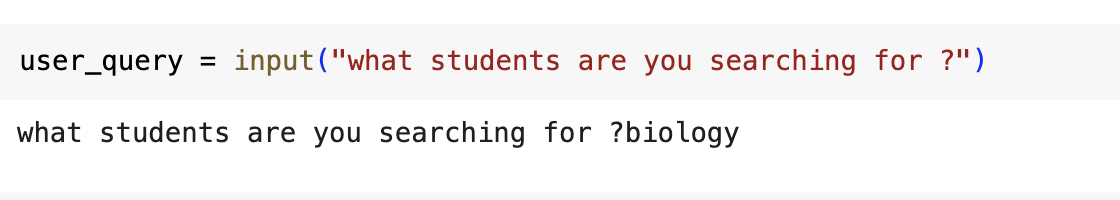

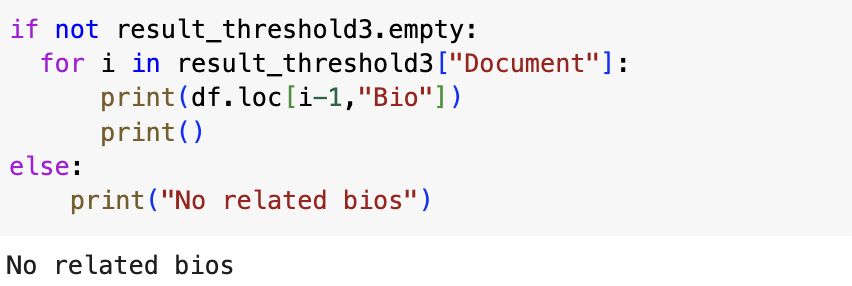

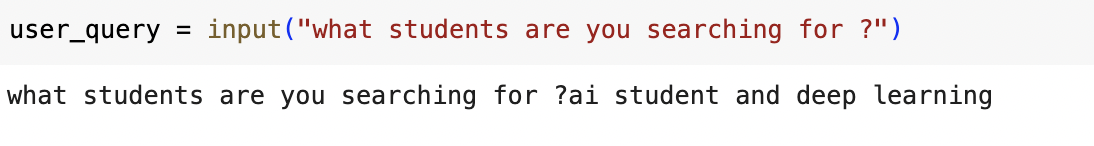

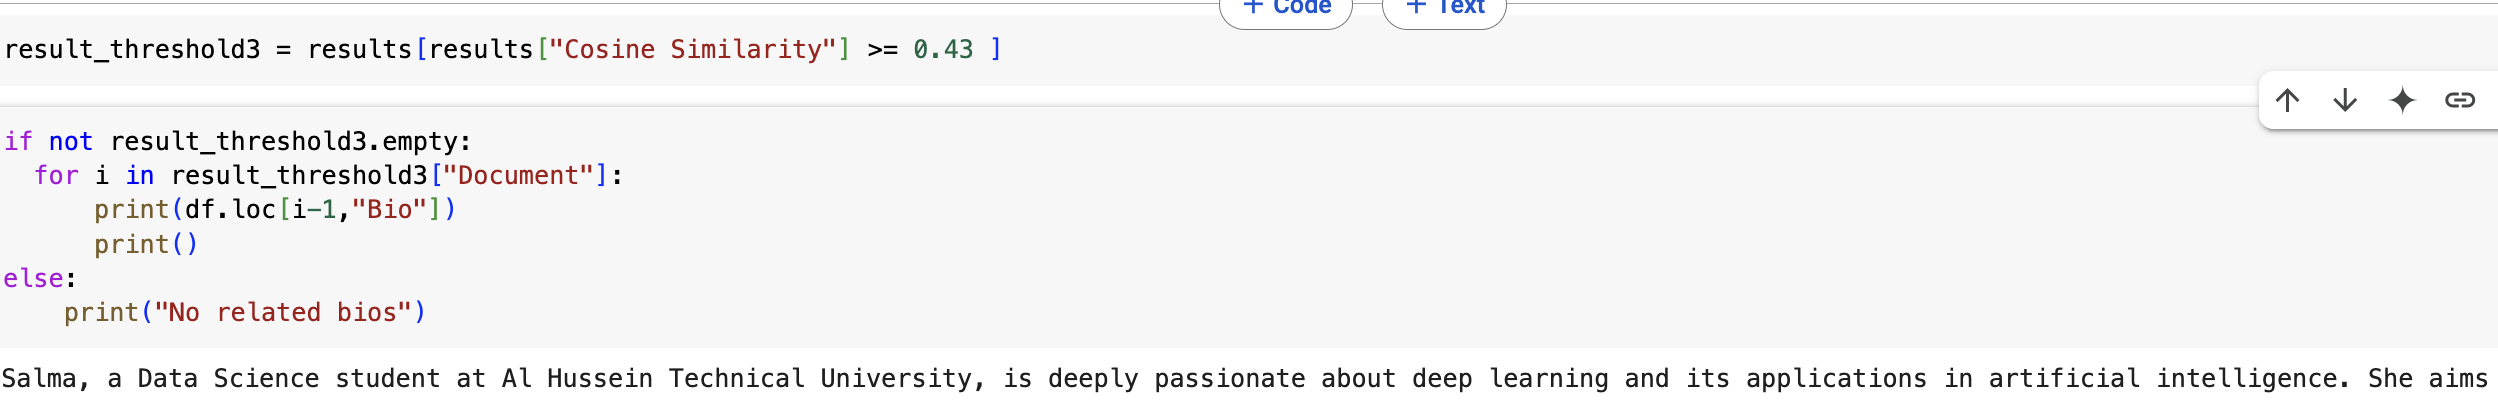

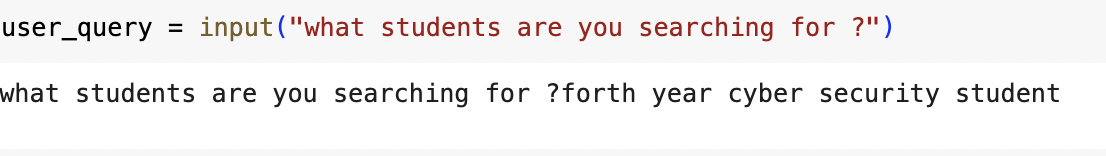

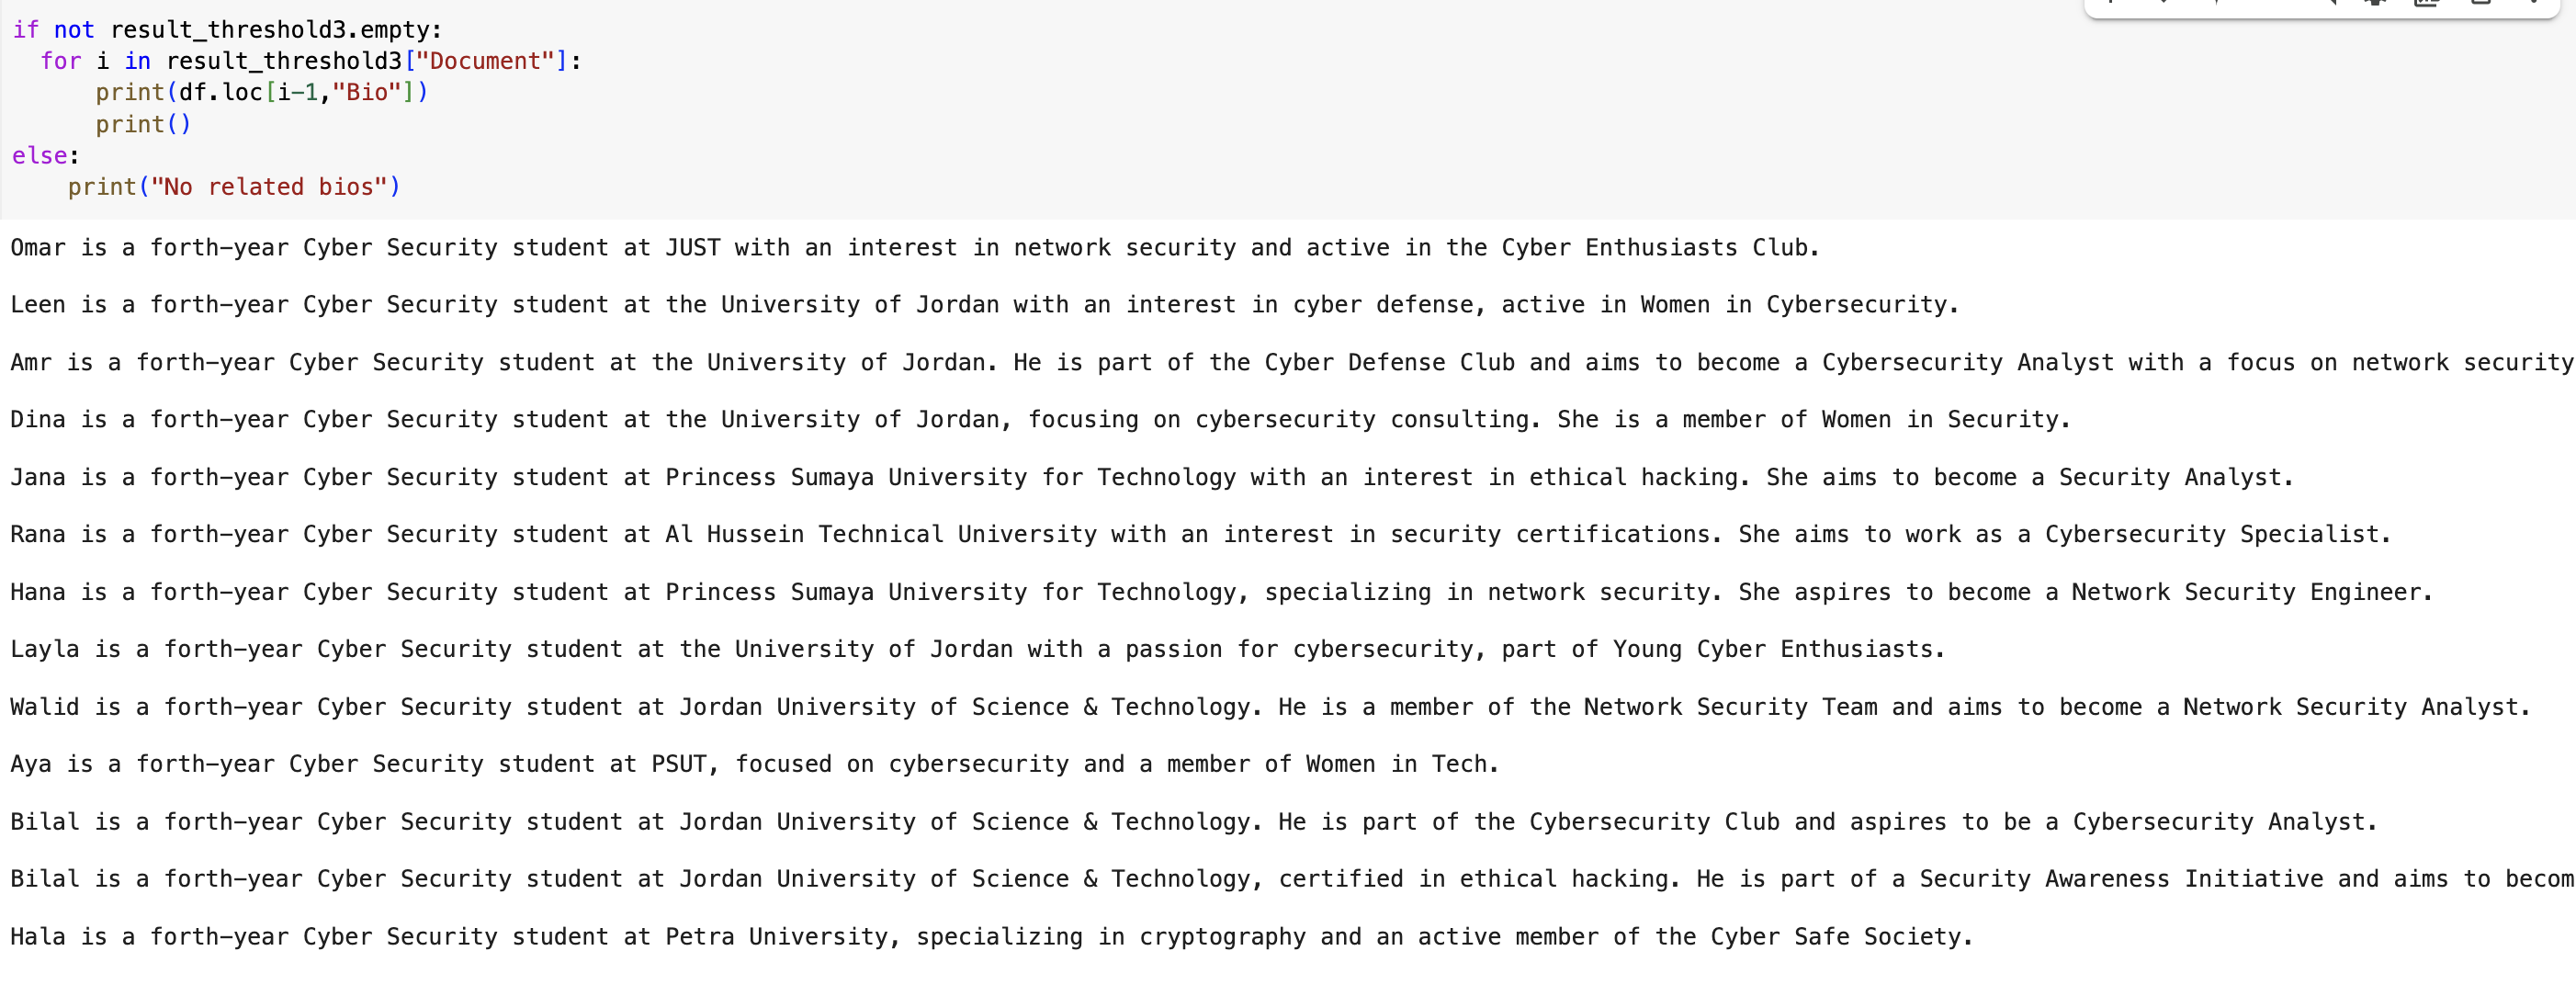

# Graph mining

In [ ]:
G = nx.DiGraph()

In [ ]:
student_name = df["Name"][0]
programming_language = df["Programming Languages"][0]
programming_language = programming_language.split(";")
programming_language.append(student_name)
print(programming_language)

['Python', ' R', ' SQL', 'Laila Mansour']


In [ ]:
G.add_nodes_from(programming_language)

In [ ]:
edges = [(programming_language[-1], programming_language[0]),
          (programming_language[-1], programming_language[1]),
          (programming_language[-1], programming_language[2])]
G.add_edges_from(edges)

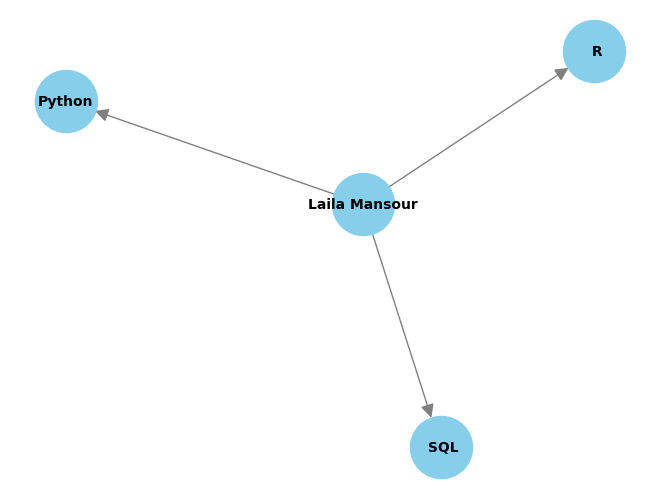

In [ ]:
pos = nx.spring_layout(G)
nx.draw(G, pos,
        with_labels=True, arrows=True,
        arrowsize=20,
        node_size=2000,
        node_color='skyblue',
        font_size=10, font_color='black', font_weight='bold', edge_color='gray', linewidths=1)


plt.savefig("Graph.png", format="PNG")
plt.show(block=False)

# graph mining real life scenario

In [ ]:
certificate = input("enter the name of the certificate:")

enter the name of the certificate:Certified Ethical Hacker (CEH)


In [ ]:
certificate= certificate.lower()
df["Certifications"]= df["Certifications"].apply(lambda i :i.lower())

In [ ]:
name = list(df.loc[(df['Certifications'] == certificate), 'Name'])
name.append(certificate)

In [ ]:
weights = list(df.loc[(df['Certifications'] == certificate), 'Project Count'])

In [ ]:
G2 = nx.DiGraph()

In [ ]:
G2.add_nodes_from(name)

In [ ]:
name.remove(name[-1])

In [ ]:
edges_weights =pd.DataFrame(columns = ["source","target","weight"])

In [ ]:
for i in range (len(name)):
  edges_weights.loc[i,"source"]= certificate
  edges_weights.loc[i,"target"]= name[i]
  edges_weights.loc[i,"weight"]= weights[i]

In [ ]:
G2.add_edges_from(edges_weights[['source', 'target']].values)

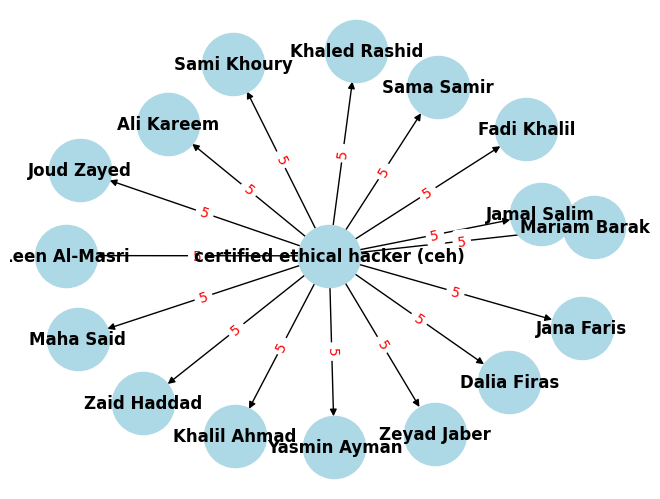

In [ ]:
G2 = nx.from_pandas_edgelist(edges_weights, 'source', 'target', ['weight'], create_using=nx.DiGraph())


pos = nx.spring_layout(G2)


nx.draw(G2 , pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=12, font_weight='bold')

edge_labels = nx.get_edge_attributes(G2, 'weight')

nx.draw_networkx_edge_labels(G2, pos, edge_labels=edge_labels, font_size=10, font_color='red')

plt.show()

# preparing the dataset for clustering

**Seperating the dataset where the label column is dropped**

In [ ]:
df.drop("Bio_ready", axis=1, inplace=True)
X = df.drop("Cluster", axis=1)
Y = df["Cluster"]

**Encoding**

In [ ]:
le = LabelEncoder()
columns_to_encode = ["Name","Programming Languages","Certifications","Extracurricular Activities","Career Interest","Bio"]
for i in  columns_to_encode:
  X[i] = le.fit_transform(X[i])

In [ ]:
X.dtypes

,0
Name,int64
Year,int64
Programming Languages,int64
Certifications,int64
Project Count,int64
Extracurricular Activities,int64
Career Interest,int64
Bio,int64


standardization

In [ ]:
s = StandardScaler()
X_scaled=s.fit_transform(X)
X_scaled= pd.DataFrame(X_scaled, columns = X.columns)

In [ ]:
X_scaled.head()

,Name,Year,Programming Languages,Certifications,Project Count,Extracurricular Activities,Career Interest,Bio
0,-0.537260,-0.492000,0.686238,0.006745,0.000000,-1.570826,-0.473007,-0.539164
1,0.412554,1.651118,-1.882157,-0.881607,1.236835,-0.739414,-1.075300,-1.725324
2,0.806048,-1.563559,-1.977283,0.830095,-1.236835,0.594308,1.434254,0.768309
3,-0.659379,-0.492000,1.256992,0.006745,0.000000,1.460362,-0.473007,-0.633518
4,0.344710,0.579559,0.400861,-1.249948,1.236835,1.148582,-1.075300,-0.876141


# Feature extraction

creating lists for the scores

In [ ]:
silhouette_scores_FE = {'PCA': [],'LDA': []}
ari_scores_FE = {'PCA': [],'LDA': []}

# PCA

In [ ]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(f"Shape after applying PCA: {X_pca.shape}")

Shape after applying PCA: (257, 4)


**K-means**

In [ ]:
kmeans = KMeans(n_clusters=3).fit(X_pca)
clusters_PCA=kmeans.predict(X_pca)

**Evaluation of K-means using PCA feature extraction and with using the labels**

In [ ]:
ARI_Score_PCA = adjusted_rand_score(Y, clusters_PCA)
print("PCA ARI score: ", ARI_Score_PCA)
AMI_Score_PCA = adjusted_mutual_info_score(Y, clusters_PCA)
print("PCA AMI score: ", AMI_Score_PCA)

PCA ARI score:  0.40003821054436434
PCA AMI score:  0.4635909444125768


**Evaluation of K-means using PCA feature extraction without using the labels**

In [ ]:
sil_score_PCA = silhouette_score(X_pca, clusters_PCA)
print("PCA Silhouette score: ", sil_score_PCA)
CH_score_PCA = calinski_harabasz_score(X_pca, clusters_PCA)
print("PCA CH score: ", CH_score_PCA)
DB_index_PCA = davies_bouldin_score(X_pca, clusters_PCA)
print("PCA DB index: ", DB_index_PCA)

PCA Silhouette score:  0.3178754112794426
PCA CH score:  137.51447132185183
PCA DB index:  1.2123432027995336


**Adding silhouette and ARI scores to the lists**

In [ ]:
silhouette_scores_FE['PCA'].append(sil_score_PCA)
ari_scores_FE['PCA'].append(ARI_Score_PCA)

# LDA

In [ ]:
clf = LinearDiscriminantAnalysis()
LDA_model = clf.fit_transform(X_scaled, Y)

In [ ]:
print(f"Shape after applying LDA: {LDA_model.shape}")

Shape after applying LDA: (257, 1)


**K-means**

In [ ]:
kmeans = KMeans(n_clusters=3).fit(LDA_model)
clusters_LDA=kmeans.predict(LDA_model)

**Evaluation of K-means using LDA feature extraction and with using the labels**

In [ ]:
ARI_Score_LDA = adjusted_rand_score(Y, clusters_LDA)
print("LDA ARI score: ", ARI_Score_LDA)
AMI_Score_LDA = adjusted_mutual_info_score(Y, clusters_LDA)
print("LDA AMI score: ", AMI_Score_LDA)

LDA ARI score:  1.0
LDA AMI score:  1.0


**Evaluation of K-means using LDA feature extraction without using the labels**

In [ ]:
sil_score_LDA = silhouette_score(LDA_model, clusters_LDA)
print("Silhouette score: ", sil_score_LDA)
CH_score_LDA = calinski_harabasz_score(LDA_model, clusters_LDA)
print("CH score: ", CH_score_LDA)
DB_index_LDA = davies_bouldin_score(LDA_model, clusters_LDA)
print("DB index: ", DB_index_LDA)

Silhouette score:  1.0
CH score:  1.1768104338597134e+33
DB index:  1.1022966738251503e-08


**Adding silhouette and ARI scores to the lists**

In [ ]:
silhouette_scores_FE['LDA'].append(sil_score_LDA)
ari_scores_FE['LDA'].append(ARI_Score_LDA)

# Visualizing the results of both LDA and PCA to compare


**Bar plot for Silhouette score**

<ipython-input-94-da8577d373a2>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["LDA","PCA"], y=[silhouette_scores_FE['LDA'][0],silhouette_scores_FE['PCA'][0]], palette="Set2")


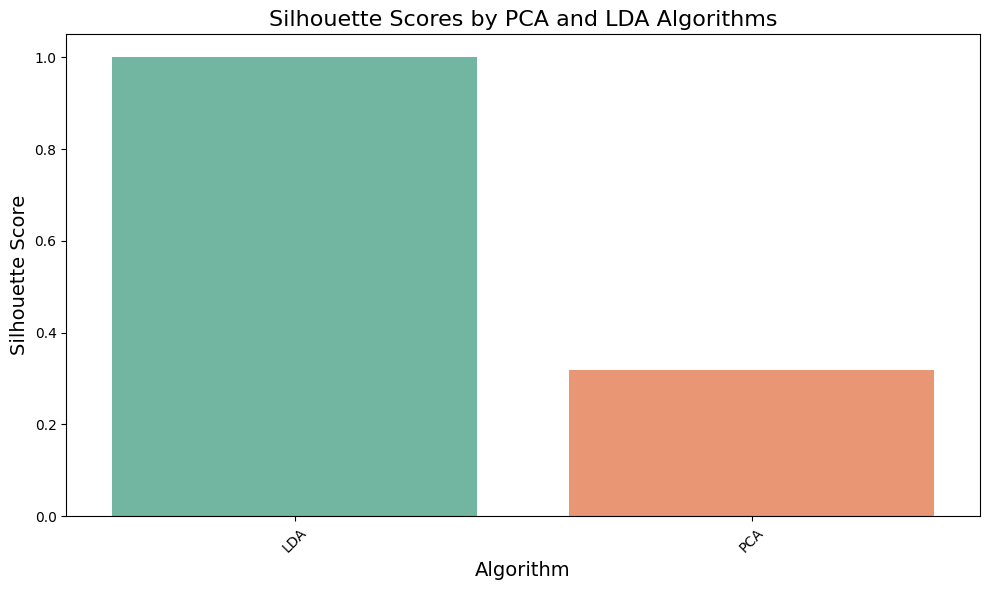

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=["LDA","PCA"], y=[silhouette_scores_FE['LDA'][0],silhouette_scores_FE['PCA'][0]], palette="Set2")
plt.title("Silhouette Scores by PCA and LDA Algorithms", fontsize=16)
plt.ylabel("Silhouette Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Bar plot for ARI score**

<ipython-input-95-3c9c59f354fd>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["LDA","PCA"], y=[ari_scores_FE['LDA'][0],ari_scores_FE['PCA'][0]], palette="Set2")


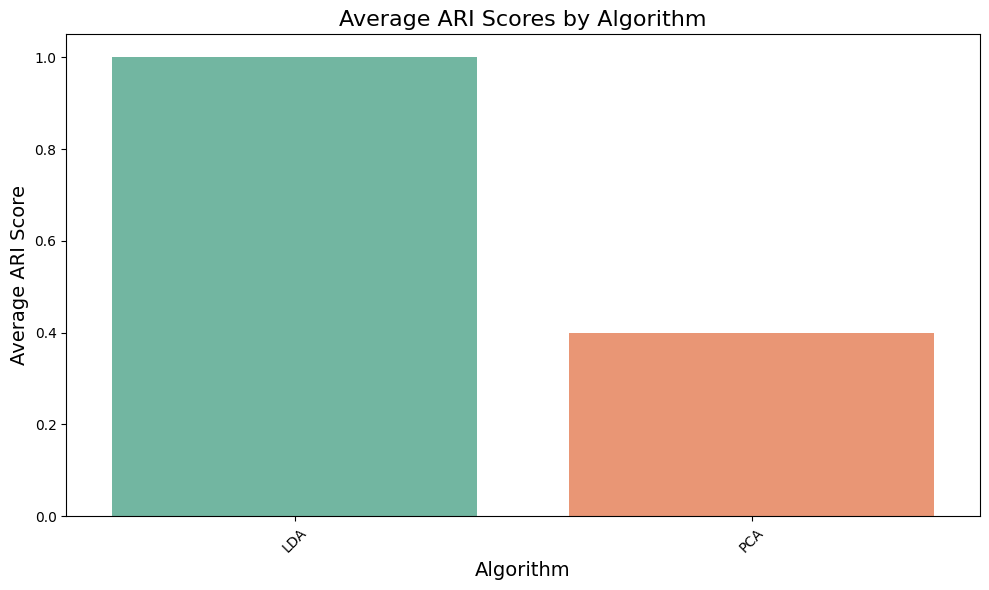

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=["LDA","PCA"], y=[ari_scores_FE['LDA'][0],ari_scores_FE['PCA'][0]], palette="Set2")
plt.title("Average ARI Scores by Algorithm", fontsize=16)
plt.ylabel("Average ARI Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


We can notice here that LDA feature extraction algorithm showed better performance as its scores were higher in all evaluation scores and it scored lower in DB index which shows that it is better as well

# clustring Algorithms

**creating lists for the scores**

In [ ]:
silhouette_scores = {'kmeans': [],'DBSCAN': [], 'HDBSCAN': [], 'OPTICS': [], 'BisectKMeans': [],
                     'Agglomerative': []}
ari_scores = {'kmeans': [],'DBSCAN': [], 'HDBSCAN': [], 'OPTICS': [], 'BisectKMeans': [],
              'Agglomerative': []}
CH_scores = {'kmeans': [],'DBSCAN': [], 'HDBSCAN': [], 'OPTICS': [], 'BisectKMeans': [],
              'Agglomerative': []}

**applying each algorithm 5 times**

In [ ]:
for i in range(5):
    print(f"iteration {i + 1}:")


    kmeans = KMeans()

    kmeans_clusters = kmeans.fit_predict(X_scaled)

    kmeans_silhouette = silhouette_score(X_scaled, kmeans_clusters)

    kmeans_ari = adjusted_rand_score(Y, kmeans_clusters)

    CH_kmeans = calinski_harabasz_score(X_scaled, kmeans_clusters)

    silhouette_scores['kmeans'].append(kmeans_silhouette)

    ari_scores['kmeans'].append(kmeans_ari)

    CH_scores['kmeans'].append(CH_kmeans)


    print(f"kmeans: Silhouette Score: {kmeans_silhouette:.4f}, ARI Score: {kmeans_ari:.4f},CH Score: {CH_kmeans:.4f}")


    dbscan = DBSCAN()

    dbscan_clusters = dbscan.fit_predict(X_scaled)

    dbscan_silhouette = silhouette_score(X_scaled, dbscan_clusters)

    dbscan_ari = adjusted_rand_score(Y, dbscan_clusters)

    CH_dbscan = calinski_harabasz_score(X_scaled, dbscan_clusters)

    silhouette_scores['DBSCAN'].append(dbscan_silhouette)

    ari_scores['DBSCAN'].append(dbscan_ari)

    CH_scores['DBSCAN'].append(CH_dbscan)

    print(f"DBSCAN: Silhouette Score: {dbscan_silhouette:.4f}, ARI Score: {dbscan_ari:.4f},CH Score: {CH_dbscan:.4f}")


    hdbscan = HDBSCAN()

    hdbscan_clusters = hdbscan.fit_predict(X_scaled)

    hdbscan_silhouette = silhouette_score(X_scaled, hdbscan_clusters)

    hdbscan_ari = adjusted_rand_score(Y, hdbscan_clusters)

    CH_hdbscan = calinski_harabasz_score(X_scaled, hdbscan_clusters)

    silhouette_scores['HDBSCAN'].append(hdbscan_silhouette)

    ari_scores['HDBSCAN'].append(hdbscan_ari)

    CH_scores['HDBSCAN'].append(CH_hdbscan)

    print(f"HDBSCAN: Silhouette Score: {hdbscan_silhouette:.4f}, ARI Score: {hdbscan_ari:.4f},CH Score: {CH_hdbscan:.4f}")


    optics = OPTICS()

    optics_clusters = optics.fit_predict(X_scaled)

    optics_silhouette = silhouette_score(X_scaled, optics_clusters)

    optics_ari = adjusted_rand_score(Y, optics_clusters)

    CH_optics = calinski_harabasz_score(X_scaled, optics_clusters)

    silhouette_scores['OPTICS'].append(optics_silhouette)

    ari_scores['OPTICS'].append(optics_ari)

    CH_scores['OPTICS'].append(CH_optics)



    print(f"OPTICS: Silhouette Score: {optics_silhouette:.4f}, ARI Score: {optics_ari:.4f},CH Score: {CH_optics:.4f}")


    bisect_kmeans = BisectingKMeans(n_clusters=3)

    bisect_kmeans_clusters = bisect_kmeans.fit_predict(X_scaled)

    bisect_kmeans_silhouette = silhouette_score(X_scaled, bisect_kmeans_clusters)

    bisect_kmeans_ari = adjusted_rand_score(Y, bisect_kmeans_clusters)

    CH_bisect_kmeans = calinski_harabasz_score(X_scaled, bisect_kmeans_clusters)

    silhouette_scores['BisectKMeans'].append(bisect_kmeans_silhouette)

    ari_scores['BisectKMeans'].append(bisect_kmeans_ari)

    CH_scores['BisectKMeans'].append(CH_bisect_kmeans)

    print(f"BisectKMeans: Silhouette Score: {bisect_kmeans_silhouette:.4f}, ARI Score: {bisect_kmeans_ari:.4f},CH Score: {CH_bisect_kmeans:.4f}")


    agglomerative = AgglomerativeClustering(n_clusters=4)

    agglomerative_clusters = agglomerative.fit_predict(X_scaled)

    agglomerative_silhouette = silhouette_score(X_scaled, agglomerative_clusters)

    agglomerative_ari = adjusted_rand_score(Y, agglomerative_clusters)

    CH_agglomerative = calinski_harabasz_score(X_scaled, agglomerative_clusters)

    silhouette_scores['Agglomerative'].append(agglomerative_silhouette)

    ari_scores['Agglomerative'].append(agglomerative_ari)

    CH_scores['Agglomerative'].append(CH_agglomerative)

    print(f"AgglomerativeClustering: Silhouette Score: {agglomerative_silhouette:.4f}, ARI Score: {agglomerative_ari:.4f}, CH Score: {CH_agglomerative:.4f}")




iteration 1:
kmeans: Silhouette Score: 0.1991, ARI Score: 0.2632,CH Score: 53.4248
DBSCAN: Silhouette Score: -0.0647, ARI Score: 0.0000,CH Score: 4.2651
HDBSCAN: Silhouette Score: 0.0993, ARI Score: 0.4836,CH Score: 31.8941
OPTICS: Silhouette Score: -0.1142, ARI Score: 0.0276,CH Score: 8.5230
BisectKMeans: Silhouette Score: 0.2523, ARI Score: 0.4319,CH Score: 96.5410
AgglomerativeClustering: Silhouette Score: 0.2350, ARI Score: 0.4847, CH Score: 70.1017
iteration 2:
kmeans: Silhouette Score: 0.2224, ARI Score: 0.4229,CH Score: 60.2906
DBSCAN: Silhouette Score: -0.0647, ARI Score: 0.0000,CH Score: 4.2651
HDBSCAN: Silhouette Score: 0.0993, ARI Score: 0.4836,CH Score: 31.8941
OPTICS: Silhouette Score: -0.1142, ARI Score: 0.0276,CH Score: 8.5230
BisectKMeans: Silhouette Score: 0.2502, ARI Score: 0.4427,CH Score: 95.7474
AgglomerativeClustering: Silhouette Score: 0.2350, ARI Score: 0.4847, CH Score: 70.1017
iteration 3:
kmeans: Silhouette Score: 0.1944, ARI Score: 0.3955,CH Score: 58.8866
D

# Visualizing the results of all clustering algorithms to compare

**Box plot for Silhouette score**

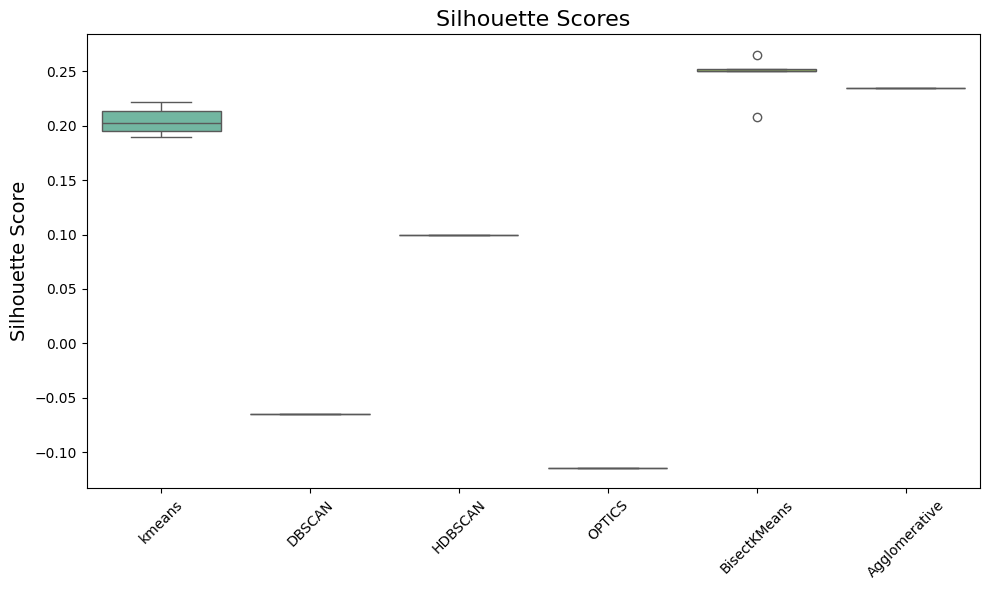

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=silhouette_scores, palette="Set2")
plt.title("Silhouette Scores", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Silhouette Score", fontsize=14)
plt.tight_layout()
plt.show()

**Box plot for ARI score**

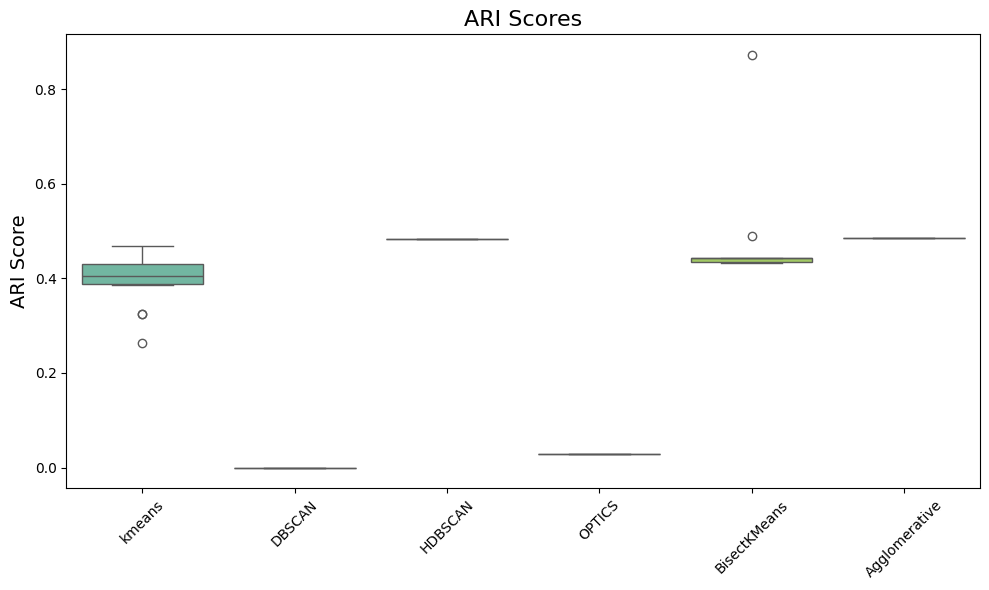

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=ari_scores, palette="Set2")
plt.title("ARI Scores", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("ARI Score", fontsize=14)
plt.tight_layout()
plt.show()

**Box plot for CH score**

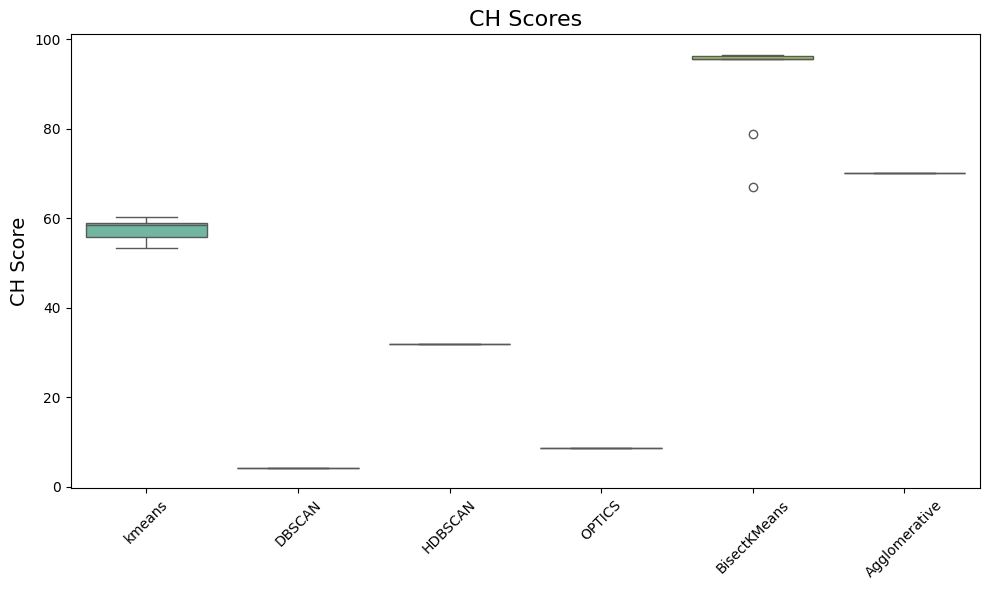

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=CH_scores, palette="Set2")
plt.title("CH Scores", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("CH Score", fontsize=14)
plt.tight_layout()
plt.show()

**Bar plot for Silhouette score**

<ipython-input-147-3a55fdd83ca1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(silhouette_avg.keys()), y=list(silhouette_avg.values()), palette="Set2")


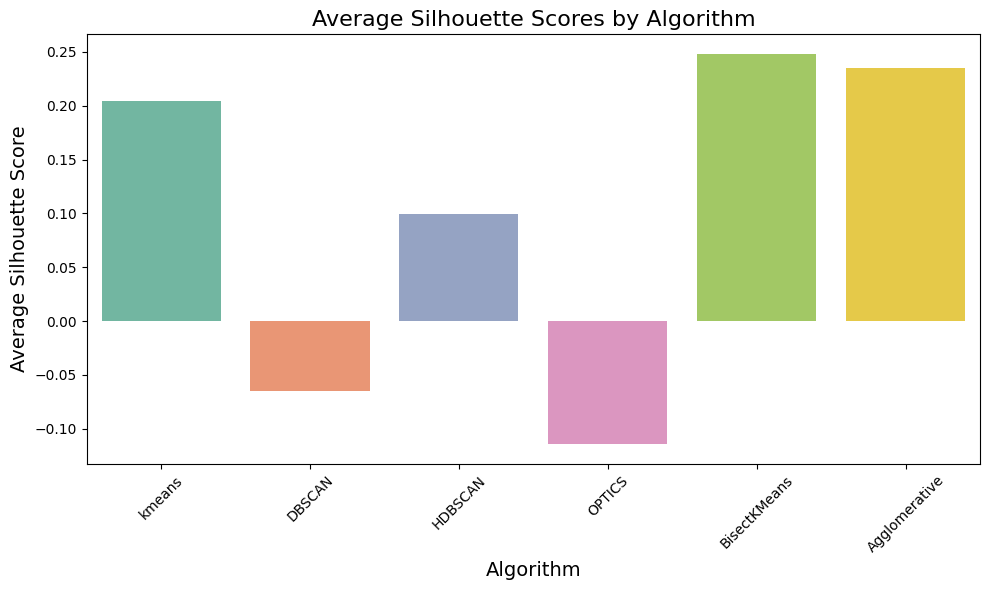

In [ ]:
silhouette_avg = {key: np.mean(values) for key, values in silhouette_scores.items()}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(silhouette_avg.keys()), y=list(silhouette_avg.values()), palette="Set2")
plt.title("Average Silhouette Scores by Algorithm", fontsize=16)
plt.ylabel("Average Silhouette Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Bar plot for ARI score**

<ipython-input-145-ced8cb8ffb45>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ari_avg.keys()), y=list(ari_avg.values()), palette="Set2")


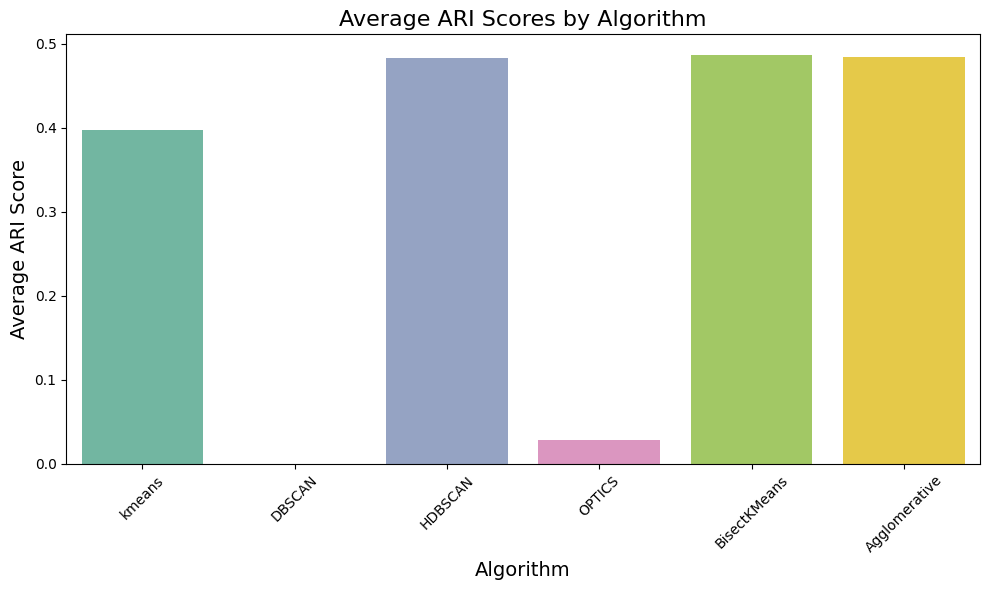

In [ ]:
ari_avg = {key: np.mean(values) for key, values in ari_scores.items()}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(ari_avg.keys()), y=list(ari_avg.values()), palette="Set2")
plt.title("Average ARI Scores by Algorithm", fontsize=16)
plt.ylabel("Average ARI Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Bar plot for CH score**

<ipython-input-146-520c12045072>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(CH_avg.keys()), y=list(CH_avg.values()), palette="Set2")


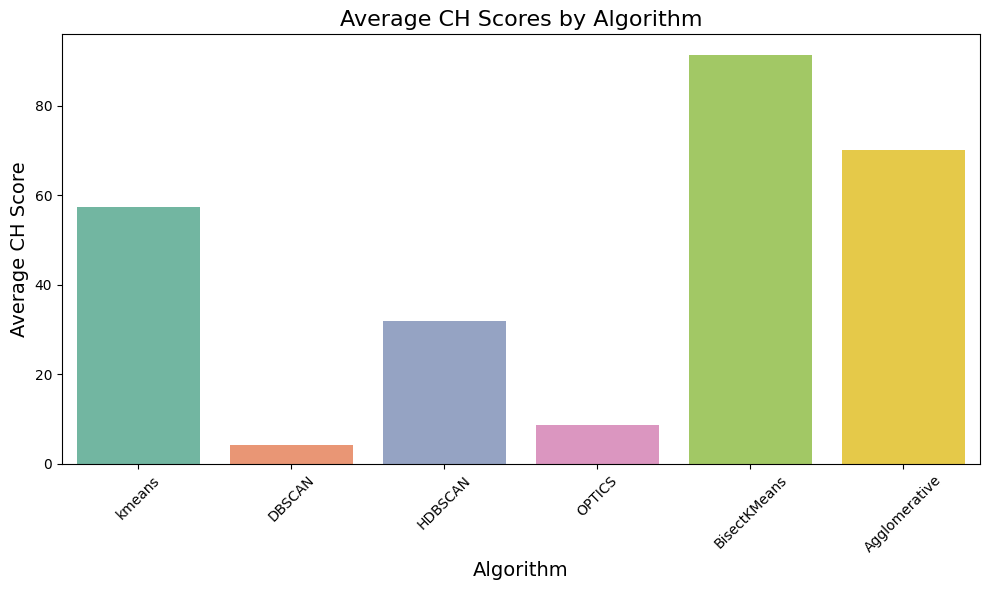

In [ ]:
CH_avg = {key: np.mean(values) for key, values in CH_scores.items()}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(CH_avg.keys()), y=list(CH_avg.values()), palette="Set2")
plt.title("Average CH Scores by Algorithm", fontsize=16)
plt.ylabel("Average CH Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Analysis**

Based on the results we can notice that for this dataset the best clustering model to be used is BisetKmeans which it had the highest CH and Silhouette scores, in second place comes the Agglomerative algorithm where it had the highest ARI score and the second highest CH and Silhouette scores. On the other hand, HDBSCAN and Kmwans had a moderate performance but k means is better because it scored higher in CH and Silhouette scores. In the last place comes optics and dbscan algorithms as they had the worst scores.